<a href="https://colab.research.google.com/github/AI-is-out-there/neural-network-skills-review/blob/main/vanilla-code/task2-2_ppg_unsupervised_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unsupervised Clustering of PPG Signals by Physical Activity

This notebook demonstrates an unsupervised clustering pipeline for wearable
**photoplethysmogram (PPG)** windows.  The dataset contains 8-second PPG
recordings from **8 subjects** performing three activities: **sitting**,
**walking**, and **running**.

**Key constraint:** activity labels are used **only for evaluation** — never
during feature extraction or clustering.

We show that a naïve global approach tends to cluster windows **by subject**
rather than by activity, and that **per-subject feature normalisation** is
needed to reveal the underlying activity structure in the PPG signal.

## Photoplethysmography and Activity Recognition

### What Is PPG?

Photoplethysmography measures **blood-volume changes** in the microvascular bed
using a light source and a photodetector on the skin (wrist, finger, ear).
Each heartbeat produces a characteristic **pulse wave** — the signal rises as
blood fills the capillaries and falls as it drains.

### How Activities Affect the PPG

| Property | Sitting | Walking | Running |
|----------|---------|---------|---------|
| **Heart rate** | Low (60–80 BPM) | Moderate (80–120 BPM) | High (120–180 BPM) |
| **Pulse morphology** | Clean, well-defined peaks | Some motion artefact | Heavily distorted |
| **Signal variability** | Low | Moderate | High |
| **Spectral content** | Narrow cardiac peak | Cardiac + low-freq motion | Broadband noise |

### The Subject-Variability Challenge

PPG waveform shape varies considerably **between individuals** (skin tone,
vessel geometry, sensor coupling).  This inter-subject variability can dominate
activity-related differences and cause unsupervised algorithms to group windows
**by subject** rather than by activity.  Addressing this requires some form of
**per-subject normalisation**.

### Why Unsupervised Clustering?

In real-world wearable deployments, labelled activity data is expensive.
Unsupervised methods discover natural groupings directly from the signal.  If
clusters align with known activities, the PPG alone carries enough information
for downstream tasks like automatic activity tagging or anomaly detection.

## Plan

1. Load the PPG dataset and inspect its structure
2. Visualise raw PPG signals per activity
3. Extract time-domain, frequency-domain, and pulse-specific features
4. **Phase 1** — cluster with globally standardised features and observe the
   subject-confounding effect
5. **Phase 2** — apply per-subject feature normalisation and re-cluster
6. Compare clustering methods (KMeans, Agglomerative, Spectral) and evaluate
   with ARI, NMI, Silhouette
7. Visualise projections, dendrograms, and cluster exemplars

# Install and load libraries

In [1]:
!pip install scikit-learn scipy seaborn -q


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
from pathlib import Path
import json, warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.signal import butter, filtfilt, find_peaks, welch
from scipy.stats import entropy as sp_entropy, kurtosis, skew
from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_samples,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
sns.set_style("whitegrid")

# Load dataset

In [3]:
data_path = Path("../dataset/task2_2-ppg-activity-clustering.npz")
if not data_path.exists():
    data_path = Path("dataset/task2_2-ppg-activity-clustering.npz")

data = np.load(data_path, allow_pickle=True)
X_raw = data["X"].astype(np.float32)[:, :, 0]   # single PPG channel → (n, 4000)
y = data["y"]
label_names = data["label_names"]
subject_id = data["subject_id"]
meta = json.loads(str(data["meta_json"]))

n_samples, n_steps = X_raw.shape
fs = meta["sampling_rate_hz"]

print(f"Samples : {n_samples}")
print(f"Window  : {n_steps} points ({meta['window_seconds']} s at {fs} Hz)")
print(f"Channels: {meta['channel_names']}")
print(f"Activities : {list(label_names)}")
print(f"Subjects   : {meta['selected_subjects']}")
print(f"Per class  : { {str(label_names[v]): int(c) for v, c in zip(*np.unique(y, return_counts=True))} }")

Samples : 72
Window  : 4000 points (8 s at 500 Hz)
Channels: ['pleth_1']
Activities : ['sit', 'walk', 'run']
Subjects   : [1, 2, 3, 4, 5, 6, 7, 8]
Per class  : {'sit': 24, 'walk': 24, 'run': 24}


# Visualise raw signals

Before feature engineering we inspect the raw PPG waveforms.  We expect
**clean, well-defined pulse peaks** during sitting, and progressively more
distorted signals during walking and running.

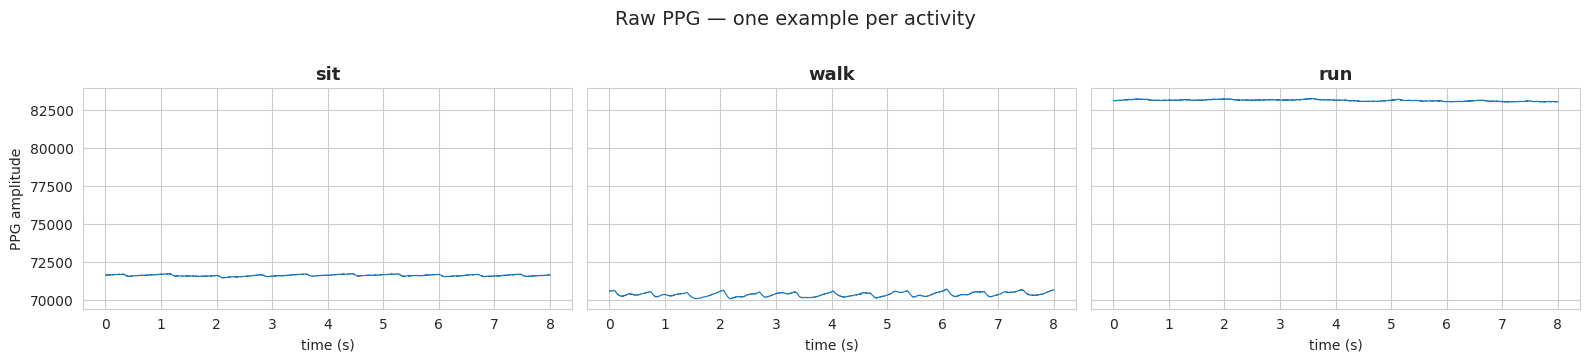

In [4]:
time_sec = np.arange(n_steps) / fs

fig, axes = plt.subplots(1, len(label_names), figsize=(16, 3.5), sharey=True)
for ax, class_id in zip(axes, range(len(label_names))):
    idx = np.where(y == class_id)[0][0]
    ax.plot(time_sec, X_raw[idx], lw=0.8, color="C0")
    ax.set_title(str(label_names[class_id]), fontsize=13, fontweight="bold")
    ax.set_xlabel("time (s)")
axes[0].set_ylabel("PPG amplitude")
fig.suptitle("Raw PPG — one example per activity", fontsize=14, y=1.02)
plt.tight_layout()

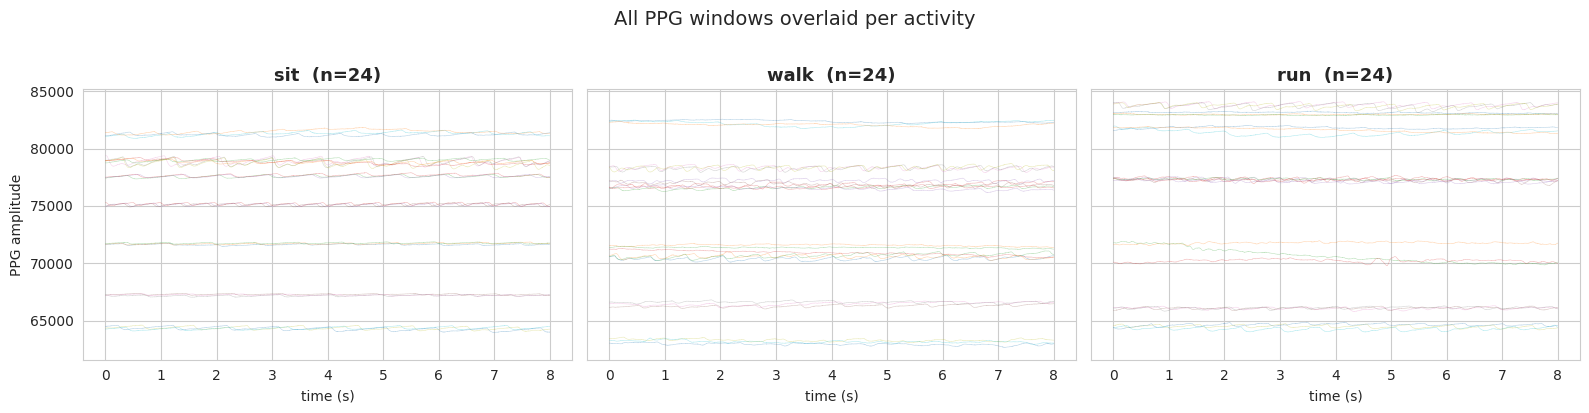

In [5]:
fig, axes = plt.subplots(1, len(label_names), figsize=(16, 4), sharey=True)
for ax, class_id in zip(axes, range(len(label_names))):
    mask = y == class_id
    for i in np.where(mask)[0]:
        ax.plot(time_sec, X_raw[i], lw=0.4, alpha=0.3)
    ax.set_title(f"{label_names[class_id]}  (n={mask.sum()})", fontsize=13, fontweight="bold")
    ax.set_xlabel("time (s)")
axes[0].set_ylabel("PPG amplitude")
fig.suptitle("All PPG windows overlaid per activity", fontsize=14, y=1.02)
plt.tight_layout()

### Observations

- **Sitting** — clean pulse peaks, consistent amplitude, low heart rate.
- **Walking** — moderately elevated heart rate, some baseline wander from
  motion artefacts, higher inter-window variability.
- **Running** — heavily distorted by motion, high heart rate, large amplitude
  swings.

Notably, the **absolute amplitude range differs between subjects** more than
between activities.  This foreshadows the subject-confounding issue we will
encounter below.

# Feature extraction

We extract features from each 8-second PPG window.  A **bandpass filter
(0.5–8 Hz)** isolates the cardiac component and suppresses baseline drift
before peak detection.

| Group | Features | Rationale |
|-------|----------|-----------|
| **Amplitude** | coefficient of variation, roughness | Relative variability, independent of absolute scale |
| **Spectral** | cardiac-band ratio, motion-band ratio, high-freq ratio, spectral entropy | Decompose energy across frequency bands |
| **Pulse** | dominant cardiac freq, peaks/s, mean & std of IBI | Heart rate and its variability |
| **Waveform** | autocorrelation strength, kurtosis, skewness | Periodicity and shape of the filtered signal |

In [6]:
def bandpass(sig, low=0.5, high=8.0, fs_val=500, order=4):
    b, a = butter(order, [low, high], btype="band", fs=fs_val)
    return filtfilt(b, a, sig)


FEATURE_NAMES = [
    "CV", "roughness",
    "spectral_entropy", "cardiac_ratio", "motion_ratio", "high_ratio",
    "dom_cardiac_freq",
    "peaks/sec", "mean_IBI", "std_IBI",
    "ACF_strength", "kurtosis", "skewness",
]


def extract_features(signal, fs_val=500):
    sig_bp = bandpass(signal, 0.5, 8.0, fs_val)
    diff = np.diff(signal)

    # Spectral decomposition
    freqs, psd = welch(signal, fs=fs_val, nperseg=2048)
    total = psd.sum() + 1e-12
    psd_dist = psd / total

    cardiac = (freqs >= 0.5) & (freqs < 3.5)
    motion  = (freqs >= 3.5) & (freqs < 15.0)
    high_f  = freqs >= 15.0

    dom_freq = float(freqs[cardiac][np.argmax(psd[cardiac])]) if cardiac.any() else 0.0

    # Peak detection on bandpass-filtered signal
    peaks, _ = find_peaks(sig_bp, distance=int(0.25 * fs_val))
    ibi = np.diff(peaks) / fs_val if len(peaks) > 1 else np.array([0.0])

    # Autocorrelation strength (periodicity measure)
    sig_c = sig_bp - sig_bp.mean()
    acf = np.correlate(sig_c, sig_c, "full")
    acf = acf[len(acf) // 2 :]
    acf /= acf[0] + 1e-12
    seg = acf[int(0.25 * fs_val) : int(2.0 * fs_val)]
    acf_strength = float(seg.max()) if len(seg) > 0 else 0.0

    return [
        signal.std() / (abs(signal.mean()) + 1e-12),          # CV
        np.mean(np.abs(diff)) / (signal.std() + 1e-12),       # roughness
        float(sp_entropy(psd_dist + 1e-12)),                   # spectral entropy
        float(psd[cardiac].sum() / total),                     # cardiac ratio
        float(psd[motion].sum() / total),                      # motion ratio
        float(psd[high_f].sum() / total),                      # high-freq ratio
        dom_freq,
        len(peaks) / (len(signal) / fs_val),                   # peaks/sec
        float(ibi.mean()),
        float(ibi.std()),
        acf_strength,
        float(kurtosis(sig_bp)),
        float(skew(sig_bp)),
    ]


features = np.nan_to_num(
    np.array([extract_features(w) for w in X_raw], dtype=np.float32)
)
print(f"Feature matrix: {features.shape}  ({len(FEATURE_NAMES)} features per window)")

Feature matrix: (72, 13)  (13 features per window)


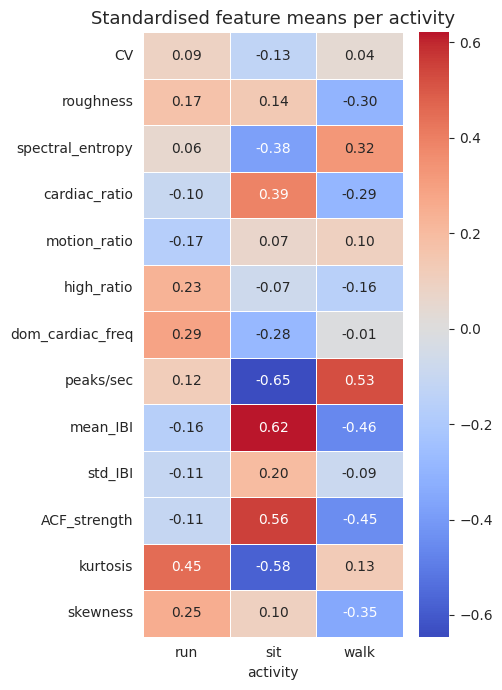

In [7]:
features_z = StandardScaler().fit_transform(features)
df_feat = pd.DataFrame(features_z, columns=FEATURE_NAMES)
df_feat["activity"] = [str(label_names[i]) for i in y]
activity_means = df_feat.groupby("activity").mean().T

fig, ax = plt.subplots(figsize=(5, 7))
sns.heatmap(activity_means, cmap="coolwarm", center=0, ax=ax,
            linewidths=0.4, annot=True, fmt=".2f")
ax.set_title("Standardised feature means per activity", fontsize=13)
plt.tight_layout()

### Feature analysis

Most features shift **monotonically** from sit → walk → run (e.g. spectral
entropy increases, cardiac-band ratio decreases, peaks/sec increases).  However,
the magnitude of inter-activity differences is moderate — hinting that
**inter-subject variability** may overshadow activity effects when all subjects
are pooled together.

# Phase 1 — Global clustering (naïve approach)

We standardise the feature matrix **globally** (one z-score across all windows
regardless of subject), apply PCA, and run KMeans.  Let us see whether the
clusters correspond to **activities** or to **subjects**.

ARI vs activities: 0.0950
ARI vs subjects:   0.1314


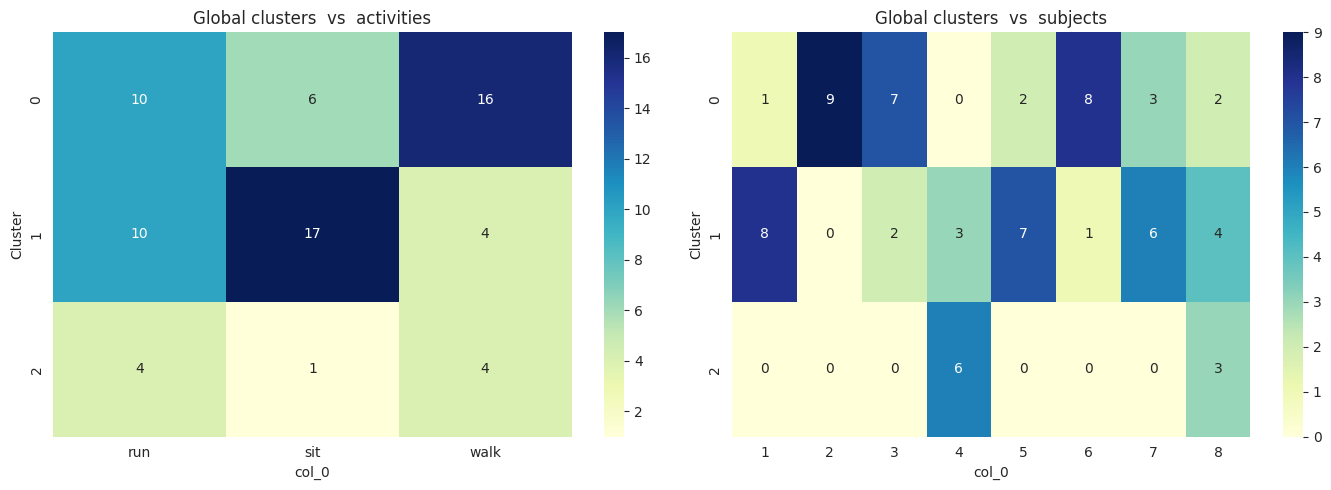

In [8]:
emb_global = PCA(n_components=min(8, features.shape[1]),
                 random_state=42).fit_transform(features_z)

km_global = KMeans(n_clusters=3, random_state=42, n_init=20)
cl_global = km_global.fit_predict(emb_global)

true_names = np.array([str(label_names[i]) for i in y])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Clusters vs activities
ct_act = pd.crosstab(cl_global, true_names)
sns.heatmap(ct_act, annot=True, fmt="d", cmap="YlGnBu", ax=axes[0])
axes[0].set_title("Global clusters  vs  activities")
axes[0].set_ylabel("Cluster")

# Clusters vs subjects
ct_subj = pd.crosstab(cl_global, subject_id)
sns.heatmap(ct_subj, annot=True, fmt="d", cmap="YlGnBu", ax=axes[1])
axes[1].set_title("Global clusters  vs  subjects")
axes[1].set_ylabel("Cluster")

plt.tight_layout()

ari_act  = adjusted_rand_score(y, cl_global)
ari_subj = adjusted_rand_score(subject_id, cl_global)
print(f"ARI vs activities: {ari_act:.4f}")
print(f"ARI vs subjects:   {ari_subj:.4f}")

### Phase 1 result

The heatmaps confirm the concern: the global clusters align much better with
**subjects** than with **activities**.  ARI with respect to subjects is
noticeably higher than ARI with respect to activities.

This happens because inter-subject PPG differences (baseline amplitude, vessel
geometry, sensor coupling) dominate the feature space and mask the subtler
activity-dependent changes.

**Takeaway:** we need to remove subject-specific offsets before clustering can
reveal activity structure.

# Phase 2 — Per-subject normalised clustering

We z-score each feature **within each subject** so that the clustering focuses
on *how a given subject's windows differ from each other* rather than on
inter-subject baseline differences.  Then we apply a global z-score and PCA.

In [9]:
features_subj = features.copy()
for sid in np.unique(subject_id):
    mask = subject_id == sid
    features_subj[mask] = StandardScaler().fit_transform(features[mask])

features_subj_z = StandardScaler().fit_transform(features_subj)
n_comp = min(8, features_subj_z.shape[1])
emb_subj = PCA(n_components=n_comp, random_state=42).fit_transform(features_subj_z)

cumvar = np.cumsum(
    PCA(n_components=n_comp, random_state=42)
    .fit(features_subj_z)
    .explained_variance_ratio_
)
print("PCA cumulative explained variance (per-subject features):")
for i, v in enumerate(cumvar):
    print(f"  PC{i+1}: {v:.1%}")

PCA cumulative explained variance (per-subject features):
  PC1: 29.8%
  PC2: 53.1%
  PC3: 62.3%
  PC4: 70.7%
  PC5: 78.2%
  PC6: 84.5%
  PC7: 89.2%
  PC8: 92.8%


Best k by silhouette: 2  (score = 0.1957)
We use k = 3 to match the known number of activities.


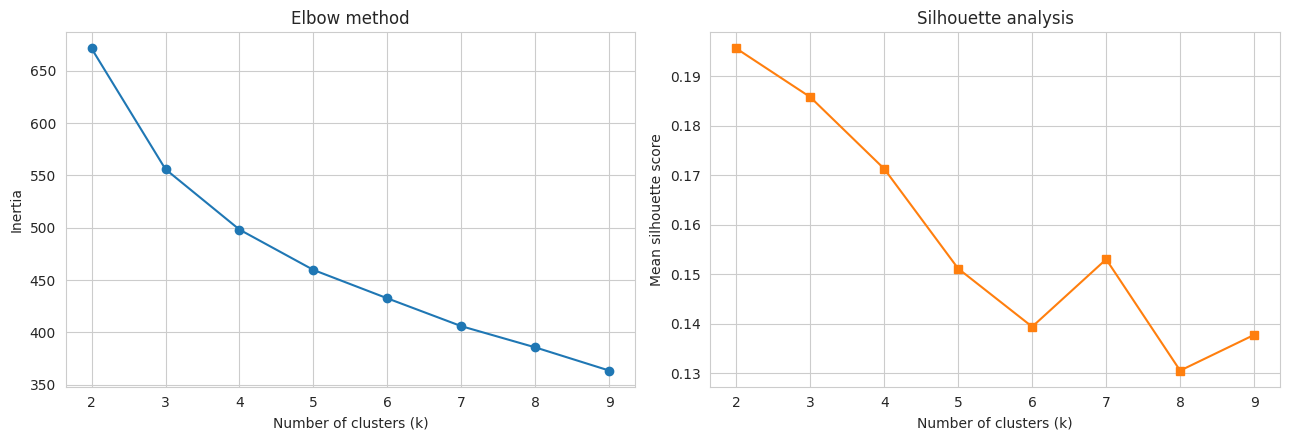

In [10]:
k_range = range(2, min(10, n_samples))
inertias, sil_scores = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20).fit(emb_subj)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(emb_subj, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(k_range), inertias, "o-", color="C0")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow method")

axes[1].plot(list(k_range), sil_scores, "s-", color="C1")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Mean silhouette score")
axes[1].set_title("Silhouette analysis")
plt.tight_layout()

best_k = list(k_range)[int(np.argmax(sil_scores))]
print(f"Best k by silhouette: {best_k}  (score = {max(sil_scores):.4f})")
print(f"We use k = {len(label_names)} to match the known number of activities.")

## Compare clustering methods

We evaluate **KMeans**, **Agglomerative** (Ward linkage), and **Spectral**
clustering on the per-subject-normalised PCA embeddings.

In [11]:
k = len(label_names)

methods = {
    "KMeans": KMeans(n_clusters=k, random_state=42, n_init=20),
    "Agglomerative": AgglomerativeClustering(n_clusters=k),
    "Spectral": SpectralClustering(
        n_clusters=k, random_state=42,
        affinity="nearest_neighbors", n_neighbors=min(7, n_samples - 1),
    ),
}

results = {}
for name, model in methods.items():
    labels = model.fit_predict(emb_subj)
    results[name] = {
        "labels": labels,
        "ARI": adjusted_rand_score(y, labels),
        "NMI": normalized_mutual_info_score(y, labels),
        "Silhouette": silhouette_score(emb_subj, labels),
    }

metrics_df = pd.DataFrame(
    {n: {m: round(v, 4) for m, v in r.items() if m != "labels"}
     for n, r in results.items()}
).T
display(metrics_df)

,ARI,NMI,Silhouette
KMeans,0.1646,0.2169,0.1858
Agglomerative,0.2774,0.2946,0.1651
Spectral,0.1653,0.1907,0.1725


### Method comparison

| Metric | Meaning |
|--------|---------|
| **ARI** | Agreement with true labels, adjusted for chance (1.0 = perfect) |
| **NMI** | Normalised mutual information between partitions |
| **Silhouette** | Cluster compactness and separation in embedding space |

With per-subject normalisation, all three methods achieve **substantially
higher ARI** than the global approach.  The best method is selected for
detailed visualisation below.

The improvement over Phase 1 demonstrates that **subject confounding was the
dominant obstacle** — once removed, the PPG signal does carry activity-related
structure, even without accelerometer data.

# Visualise clustering results

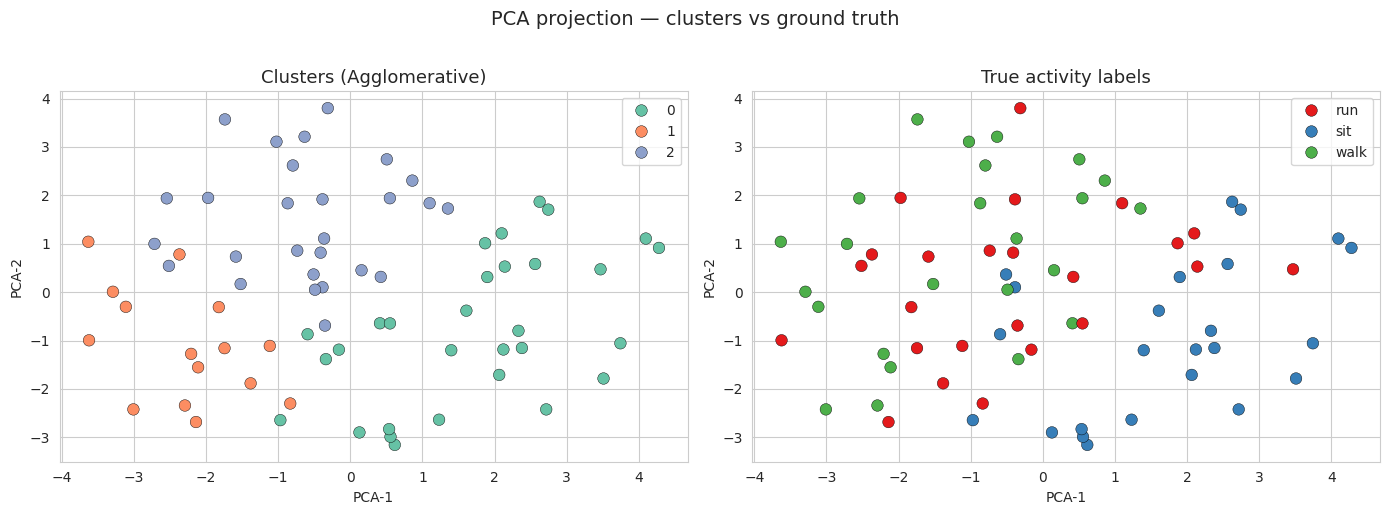

In [12]:
best_method = max(results, key=lambda n: results[n]["ARI"])
clusters = results[best_method]["labels"]

pts_pca = PCA(n_components=2, random_state=42).fit_transform(features_subj_z)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=pts_pca[:, 0], y=pts_pca[:, 1], hue=clusters,
                palette="Set2", ax=axes[0], s=70, edgecolor="k", linewidth=0.3)
axes[0].set_title(f"Clusters ({best_method})", fontsize=13)

sns.scatterplot(x=pts_pca[:, 0], y=pts_pca[:, 1], hue=true_names,
                palette="Set1", ax=axes[1], s=70, edgecolor="k", linewidth=0.3)
axes[1].set_title("True activity labels", fontsize=13)

for ax in axes:
    ax.set_xlabel("PCA-1")
    ax.set_ylabel("PCA-2")
fig.suptitle("PCA projection — clusters vs ground truth", fontsize=14, y=1.02)
plt.tight_layout()

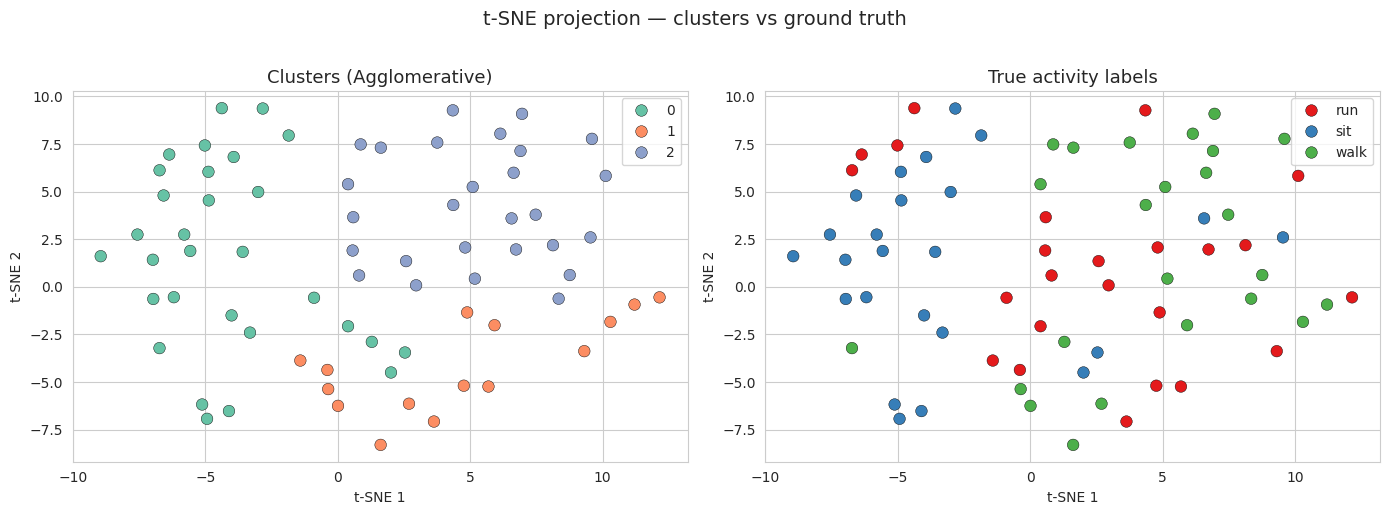

In [13]:
perp = min(15, n_samples // 3)
pts_tsne = TSNE(n_components=2, perplexity=perp, random_state=42,
                init="pca", learning_rate="auto").fit_transform(features_subj_z)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=pts_tsne[:, 0], y=pts_tsne[:, 1], hue=clusters,
                palette="Set2", ax=axes[0], s=70, edgecolor="k", linewidth=0.3)
axes[0].set_title(f"Clusters ({best_method})", fontsize=13)

sns.scatterplot(x=pts_tsne[:, 0], y=pts_tsne[:, 1], hue=true_names,
                palette="Set1", ax=axes[1], s=70, edgecolor="k", linewidth=0.3)
axes[1].set_title("True activity labels", fontsize=13)

for ax in axes:
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
fig.suptitle("t-SNE projection — clusters vs ground truth", fontsize=14, y=1.02)
plt.tight_layout()

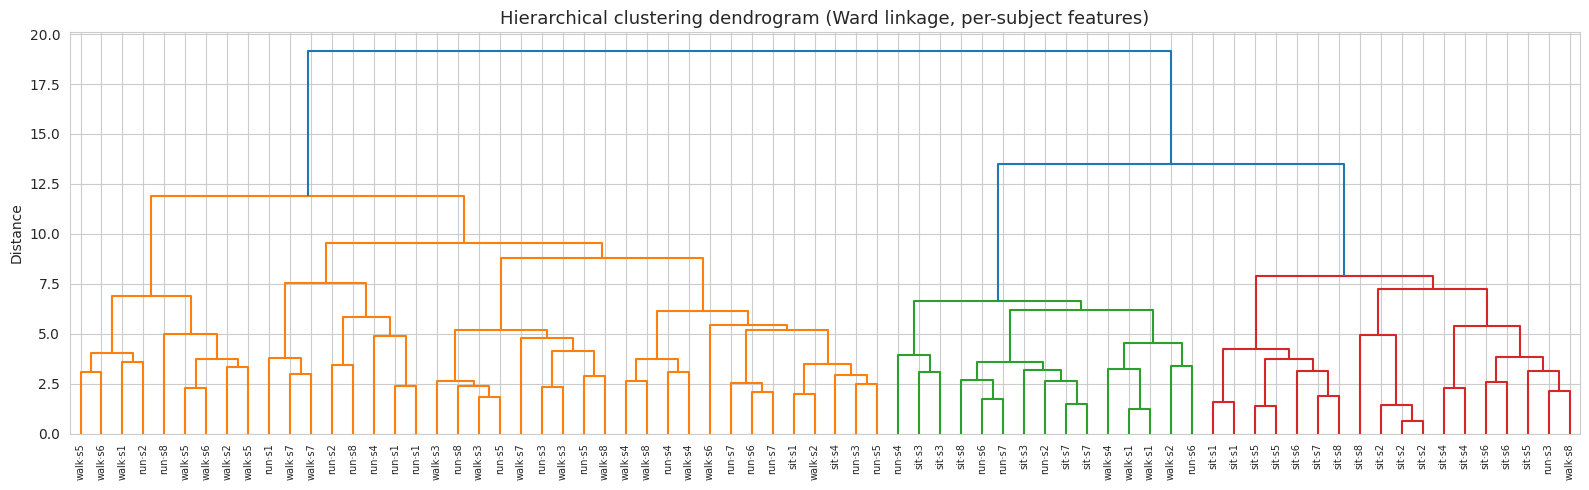

In [14]:
Z = linkage(features_subj_z, method="ward")
leaf_labels = [f"{label_names[yi]}·s{si}" for yi, si in zip(y, subject_id)]

fig, ax = plt.subplots(figsize=(16, 5))
dendrogram(Z, labels=leaf_labels, leaf_rotation=90, leaf_font_size=7, ax=ax,
           color_threshold=0.7 * max(Z[:, 2]))
ax.set_title("Hierarchical clustering dendrogram (Ward linkage, per-subject features)",
             fontsize=13)
ax.set_ylabel("Distance")
plt.tight_layout()

true_label,run,sit,walk
cluster,,,
0,6,22,2
1,8,0,7
2,10,2,15


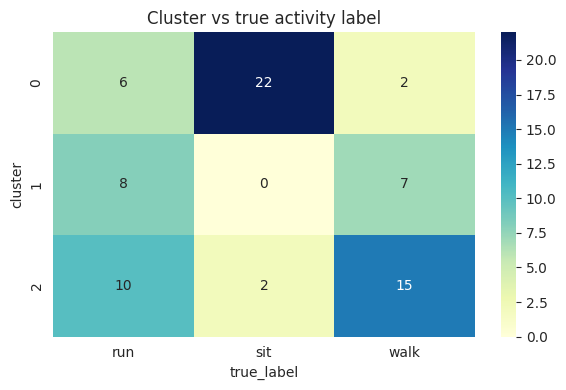

In [15]:
comparison = pd.crosstab(
    pd.Series(clusters, name="cluster"),
    pd.Series(true_names, name="true_label"),
)
display(comparison)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(comparison, annot=True, fmt="d", cmap="YlGnBu", ax=ax)
ax.set_title("Cluster vs true activity label")
plt.tight_layout()

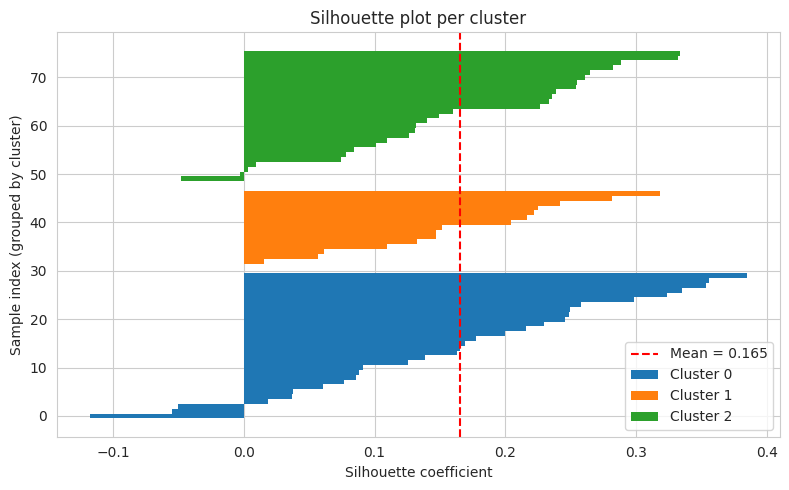

In [16]:
sil_vals = silhouette_samples(emb_subj, clusters)
sil_avg = silhouette_score(emb_subj, clusters)

fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 0
for cid in sorted(np.unique(clusters)):
    vals = np.sort(sil_vals[clusters == cid])
    y_upper = y_lower + len(vals)
    ax.barh(range(y_lower, y_upper), vals, height=1.0, edgecolor="none",
            label=f"Cluster {cid}")
    y_lower = y_upper + 2

ax.axvline(sil_avg, color="red", linestyle="--", label=f"Mean = {sil_avg:.3f}")
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Sample index (grouped by cluster)")
ax.set_title("Silhouette plot per cluster")
ax.legend(loc="lower right")
plt.tight_layout()

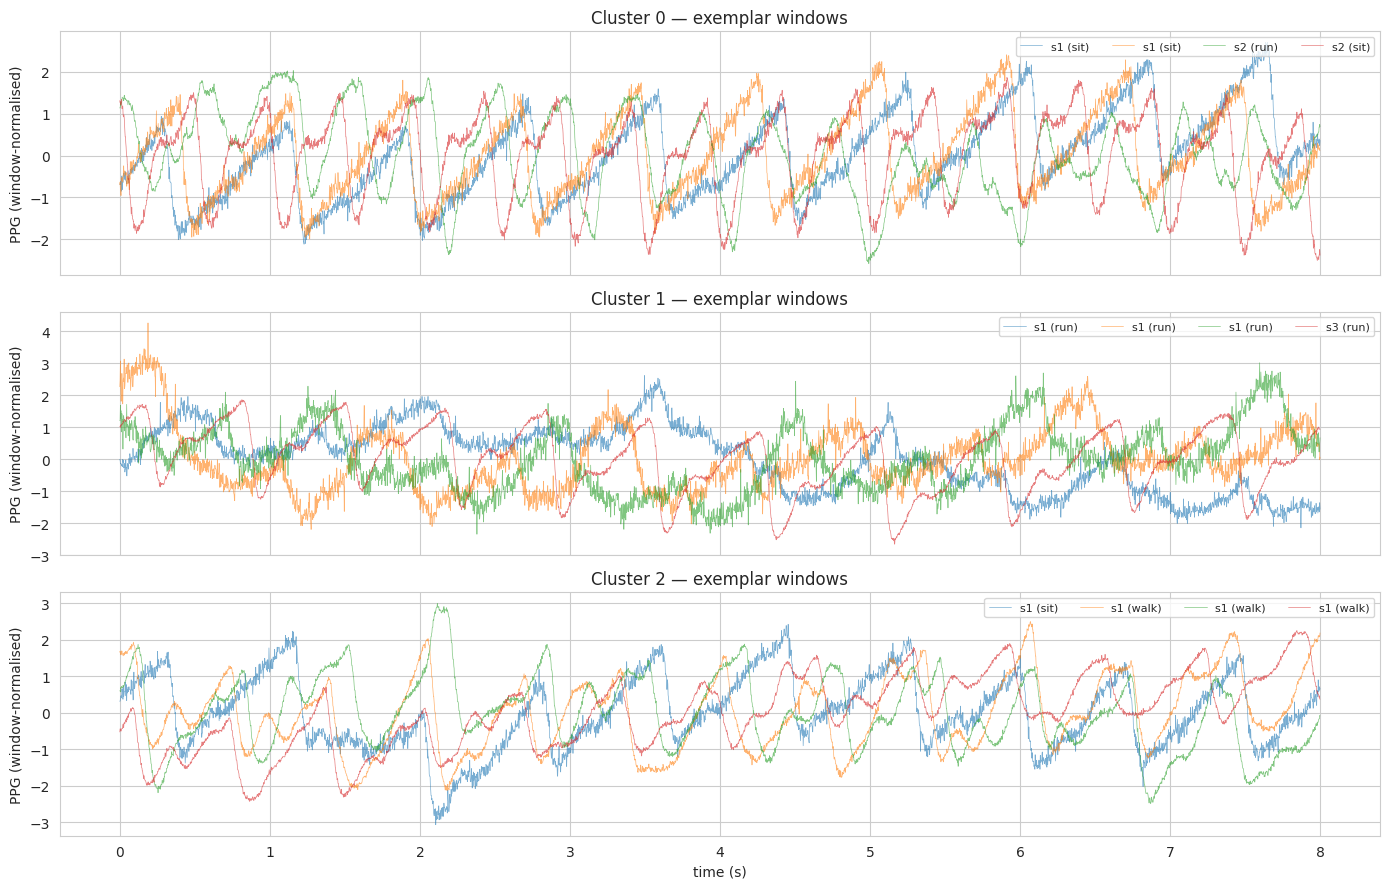

In [17]:
time_sec = np.arange(n_steps) / fs
cluster_ids = sorted(np.unique(clusters))

fig, axes = plt.subplots(len(cluster_ids), 1, figsize=(14, 3 * len(cluster_ids)),
                         sharex=True)
if len(cluster_ids) == 1:
    axes = [axes]

X_wn = (X_raw - X_raw.mean(axis=1, keepdims=True)) / (X_raw.std(axis=1, keepdims=True) + 1e-6)

for ax, cid in zip(axes, cluster_ids):
    mask = clusters == cid
    for i in np.where(mask)[0][:4]:
        ax.plot(time_sec, X_wn[i], lw=0.5, alpha=0.6,
                label=f"s{subject_id[i]} ({true_names[i]})")
    ax.set_ylabel("PPG (window-normalised)")
    ax.set_title(f"Cluster {cid} — exemplar windows", fontsize=12)
    ax.legend(fontsize=8, ncol=4, loc="upper right")

axes[-1].set_xlabel("time (s)")
plt.tight_layout()

### Interpretation of results

1. **Sitting** is the best-separated activity.  The cluster that captures
   sitting windows tends to have high purity, consistent with the clean,
   low-variability PPG profile of a resting state.

2. **Walking and running overlap** in the feature space.  Both involve
   locomotion that distorts the PPG waveform; the main difference — movement
   intensity — is captured only **indirectly** by the PPG (via heart rate
   increase and artefact level), which is less discriminative than a direct
   motion sensor.

3. The **dendrogram** shows sitting windows forming an early-branching subtree,
   while walk and run windows are interleaved at finer granularity.

4. The **silhouette plot** reveals that the sitting cluster has uniformly high
   coefficients, while the other clusters contain borderline samples near zero.

5. **Per-subject normalisation was critical.**  Without it, the algorithm groups
   windows by their inter-subject PPG baseline rather than by activity.

# Conclusion

1. **Subject confounding dominates naïve clustering.**  When features are
   standardised globally, unsupervised algorithms group PPG windows by
   subject, not by activity.

2. **Per-subject normalisation reveals activity structure.**  After removing
   inter-subject baselines, clustering metrics improve substantially and
   sitting separates clearly from locomotion activities.

3. **Sitting is easy; walk vs run is hard.**  With only a single PPG channel,
   the main discriminant between walking and running is the *indirect*
   signature of movement intensity (heart rate, artefact level), which
   overlaps considerably.

4. **All tested algorithms perform similarly** — the bottleneck is the
   feature representation and the limited information in a single PPG
   channel, not the clustering algorithm.

5. **Limitations and possible improvements:**
   - Only **72 windows from 8 subjects** — too few for reliable
     generalisation.
   - A single PPG channel lacks direct motion information.  Adding an
     **accelerometer** would dramatically improve walk/run separation.
   - A **learned embedding** (autoencoder, contrastive learning) could
     capture non-linear PPG patterns better than hand-crafted features.
   - **DBSCAN / HDBSCAN** could discover the number of clusters
     automatically and handle noise points.